## Finding Marginals & Applying Time-Varying Copulas

In this notebook, we build a time-varying multivariate model to capture the dependence between coastal flooding drivers — Non-Tidal Residuals (NTR), Rainfall (RF), and River Discharge (RD) — using time-varying copulas and marginal distributions. This allows us to estimate dynamic joint probabilities and return periods over time.

# Step 1: Marginal Distributions

We first fit marginal distributions to each variable:
*For the center variable (the one used in the POT analysis), we fit a time-varying Generalized Pareto (GP) distribution to model extreme values.
*For the other variables, we identify and fit the most appropriate marginal distributions (e.g., Gamma, Lognormal, Weibull, etc.) based on goodness-of-fit statistics (AIC/BIC).
This step transforms each variable into uniform marginals via their respective CDFs, which are required inputs for copula models.

## Step 2: Time-Varying Copula Model

Next, we apply a time-varying copula to the uniform marginals.
The copula parameters are modeled as smooth functions of time, allowing the dependence structure between variables to evolve over the historical record.
We use these time-varying copulas to simulate synthetic joint samples that preserve both the marginal behavior and the changing dependence patterns over time.

## Step 3: Return Period Estimation

Using the simulated joint distribution, we compute:
* Marginal and joint exceedance probabilities
* Dynamic return periods of compound events, accounting for temporal changes in dependence
This enables more realistic flood risk assessments than stationary models.

## Step 4: Back-Transformation

Finally, we apply the inverse marginal CDFs to map the synthetic uniform samples back to their original physical scales (e.g., rainfall in mm, surge in m, discharge in m³/s).
This gives realistic synthetic events that can be used as boundary conditions for hydrodynamic models or for risk mapping under non-stationary conditions.

## The only thing to keep in mind, is that sometimes the parameters of the distributions are not good enough to mimic the patterns of the original datasets (shown in the visualization part). In this case, you need to manually change the parameters to achieve good results.

In [1]:
# If we want to run this R code in Jupyter Notebook, we need to create a new environment in Anaconda Prompt

# conda create -n rjup -c conda-forge python=3.11 -y
# conda activate rjup
# conda install -c conda-forge jupyterlab r-base r-irkernel -y
# R
# install.packages('IRkernel')
# IRkernel::installspec(name = 'rjup', displayname = 'R (rjup)')
# q()

# Then start Jupyter Lab or VS Code and select rjup environment as the kernel


In [2]:
# install.packages(c(
#   "evd",
#   "MASS",
#   "fitdistrplus",
#   "lubridate",
#   "dplyr",
#   "pracma",
#   "fGarch"
# ))
# install.packages("NlcOptim")   # requires Rtools on Windows
# install.packages("evir")
# install.packages("network")
# install.packages("statnet")
# install.packages("copula")

In [1]:
# Required libraries
# Install if not already installed
# if (!requireNamespace("fitdistrplus", quietly = TRUE)) {
#   install.packages("fitdistrplus")
# }

# Load it
library(fitdistrplus)
library(VineCopula)
library(evd)
library(MASS)
library(fitdistrplus)
library(lubridate)
library(dplyr)
library(pracma)
library(fGarch)

Loading required package: MASS

Loading required package: survival


Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union



Attaching package: 'dplyr'


The following object is masked from 'package:MASS':

    select


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


NOTE: Packages 'fBasics', 'timeDate', and 'timeSeries' are no longer
attached to the search() path when 'fGarch' is attached.

If needed attach them yourself in your R script by e.g.,
        require("timeSeries")



In [6]:
# Check where you are now
# getwd()
# list.files()  # should show your CSV name; if not, you're in the wrong folder

# Set to the folder that contains the CSV
setwd("C:/Users/sadaf/Desktop/Generating_Boundary_Conditions/POT_24hr_Jan26/Trivariate/OceanSprings/TimeVarying")



## GDP

In [7]:
center_Var <- "POT_RF"  # Center variable for POT analysis
associated_var1 <- "Max_RD_in_5d"  # First associated variable
associated_var2 <- "Max_NTR_in_5d"  # Second associated variable
time_var <- "time"
year_var_loc <- "Year"
n_events_year <- 5

In [8]:

# Load data
df <- read.csv(paste0("POT_RF_TimeVarying_NTR_RD_", n_events_year, ".csv"))

df <- na.omit(df)
df <- df[df[[associated_var2]] != 0, ]
df <- df[df[[associated_var1]] != 0, ]
df <- df[df[[center_Var]] > 0, ]
df <- df[is.finite(df[[center_Var]]), ]


df_location <- read.csv(paste0("RF_TimeVarying_Thresholds_", n_events_year, ".csv"))
df_location <- df_location[df_location[[year_var_loc]] < 2025, ]

# Step 1: Time numeric
df[[time_var]] <- as.POSIXct(df[[time_var]], format = "%Y-%m-%d %H:%M:%S", tz = "UTC")
# df[[time_var]] <- as.POSIXct(df[[time_var]], format = "%m/%d/%Y %H:%M", tz = "UTC")

df <- df[order(df[[time_var]]), ]
time_years <- as.numeric(difftime(df[[time_var]], min(df[[time_var]]), units = "days")) / 365.25

elapsed_years_location <- df_location[[year_var_loc]] - min(df_location[[year_var_loc]])
lm_loc <- lm(Threshold ~ elapsed_years_location, data = df_location)

# Now compute elapsed years for every observation in df using time_years
mu_t <- predict(lm_loc, newdata = data.frame(elapsed_years_location = time_years))

# Step 4: Filter exceedances above μ(t)
mask <- which(df[[center_Var]] > mu_t)
x_obs <- df[[center_Var]][mask]
mu_obs <- mu_t[mask]
t_obs <- time_years[mask]
y_obs <- x_obs - mu_t[mask]

# Step 2: Time-varying GPD scale parameter σ(t)
neg_log_likelihood <- function(params, x, t) {
  a <- params[1]; b <- params[2]; xi <- params[3]
  sigma <- a + b * t
  
  # Replace too-small sigma values with a minimum threshold
  sigma[sigma <= 0] <- 1e-6
  
  # if any sigma non-positive or non-finite, return big value
  if (any(!is.finite(sigma)) || any(sigma <= 0)) {
    return(1e10)
  }
  
  # vectorised log-likelihood
  ll <- evd::dgpd(x, loc = 0, scale = sigma, shape = xi, log = TRUE)
  
  # if any NA/NaN/-Inf/Inf, treat as bad parameter
  if (any(!is.finite(ll))) {
    return(1e10)
  }
  
  return(-sum(ll))  # negative log-likelihood
}

init_guess <- c(0.2, 0.001, 0.1)
fit <- optim(init_guess, neg_log_likelihood,
             x = y_obs, t = t_obs,
             method = "Nelder-Mead")


a <- fit$par[1]
b <- fit$par[2]
xi <- fit$par[3]
# xi <- 0.1
# b <- 0.35

sigma_t <- a + b * t_obs

gpd_cdf <- function(x, t) {
  mu <- predict(lm_loc, newdata = data.frame(elapsed_years_location = t))
  sigma <- a + b * t
  z <- 1 + xi * (x - mu) / sigma
  ifelse(z <= 0, NA, 1 - z^(-1 / xi))
}
u_rf <- mapply(gpd_cdf, x_obs, t_obs)

In [9]:
# Number of exceedances
n_exc <- length(y_obs)
# Total number of years in record
total_years <- max(df[[time_var]]) - min(df[[time_var]])
total_years <- as.numeric(total_years, units = "days") / 365.25
lambda <- n_events_year  # events per year

# Choose a year (or time point) for prediction
t_future <- mean(t_obs)   # can use a specific time (e.g., last year)

mu_t_future <- predict(lm_loc, newdata = data.frame(elapsed_years_location = t_future))
sigma_t_future <- a + b * t_future

# Define parameters
T_values <- c(0.083, 1, 2, 5, 10, 20, 25, 50, 75 ,100)   # return periods (years)
# xi <- fit$par[3]

results <- data.frame(ReturnPeriod = T_values, ReturnLevel = NA)

for (i in seq_along(T_values)) {
  T <- T_values[i]
  
  if (abs(xi) > 1e-6) {
    z_T <- mu_t_future + (sigma_t_future / xi) * ((lambda * T)^xi - 1)
  } else {
    z_T <- mu_t_future + sigma_t_future * log(lambda * T)
  }
  
  results$ReturnLevel[i] <- round(z_T, 3)
}

# print(results)

# Optionally save to CSV
write.csv(results, "ReturnLevels_TimeVaryingGPD_RF.csv", row.names = FALSE)

# Define return periods and time grid
T_vals <- c(0.083, 1, 2, 5, 10, 20, 25, 50, 75 ,100) 
t_grid <- seq(min(t_obs), max(t_obs), length.out = 100)

# Compute return levels
return_levels <- sapply(T_vals, function(T) {
  mu_t <- predict(lm_loc, newdata = data.frame(elapsed_years_location = t_grid))
  sigma_t <- a + b * t_grid
  sigma_t[sigma_t <= 0] <- 1e-6
  
  if (abs(xi) > 1e-6) {
    mu_t + (sigma_t / xi) * ((lambda * T)^xi - 1)
  } else {
    mu_t + sigma_t * log(lambda * T)
  }
})

# Custom legend labels
legend_labels <- ifelse(T_vals == 0.083, "Monthly", paste0(T_vals, "-yr"))

# Save high-res plot
png("TimeVarying_ReturnLevels_RF.png", width = 1800, height = 1000, res = 200)

# Increase right margin to make space for legend
par(mar = c(5, 5, 4, 8))  # bottom, left, top, right

# Main plot
matplot(t_grid, return_levels, type = "l", lwd = 3, lty = 1,
        col = c("blue", "orange", "red", "purple", "green"),
        xlab = "Years (elapsed)", ylab = "NTR (m)",
        main = "Time-varying Return Levels",
        cex.axis = 1.3, cex.lab = 1.5, cex.main = 1.6)

# Legend — now includes "Monthly"
legend("topright", inset = c(-0.25, 0), xpd = TRUE,
       legend = legend_labels,
       col = c("blue", "orange", "red", "purple", "green"),
       lwd = 3, lty = 1, bty = "n",
       title = "Return Period",
       title.cex = 1.4, cex = 1.3)

dev.off()



agg_record_835907241 
                   2

## Fitting Appropriate Marginal Distributions for Associated Variables

In [35]:

rd_vals <- df[[associated_var1]][mask]
select_best_fit <- function(fit_list) {
  gof <- gofstat(fit_list)
  best_aic <- which.min(gof$aic)
  best_bic <- which.min(gof$bic)

  cat("Best AIC fit:", names(fit_list)[best_aic], "\n")
  cat("Best BIC fit:", names(fit_list)[best_bic], "\n")
  return(list(
    AIC_best = fit_list[[best_aic]],
    BIC_best = fit_list[[best_bic]],
    gof_summary = gof
  ))
}

# Example usage:
fits <- list(
  gamma = fitdist(rd_vals, "gamma"),
  lnorm = fitdist(rd_vals, "lnorm"),
  weibull = fitdist(rd_vals, "weibull"),
  norm = fitdist(rd_vals, "norm"),
  exp = fitdist(rd_vals, "exp")
)

best_fits_rd <- select_best_fit(fits)

# Extract fitted distribution name
best_fit_name_rd <- best_fits_rd$AIC_best$distname

# Extract parameter estimates
params_rd <- best_fits_rd$AIC_best$estimate

# Compute uniform marginals based on best distribution
if (best_fit_name_rd == "exp") {
  rd_vals <- df[[associated_var1]][mask]
  u_rd <- pexp(rd_vals, rate = as.numeric(params_rd["rate"]))

} else if (best_fit_name_rd == "gamma") {
  rd_vals <- df[[associated_var1]][mask]
  u_rd <- pgamma(rd_vals,
                 shape = as.numeric(params_rd["shape"]),
                 rate = as.numeric(params_rd["rate"]))

} else if (best_fit_name_rd == "lnorm") {
  rd_vals <- df[[associated_var1]][mask]
  u_rd <- plnorm(rd_vals,
                 meanlog = as.numeric(params_rd["meanlog"]),
                 sdlog = as.numeric(params_rd["sdlog"]))

} else if (best_fit_name_rd == "weibull") {
  rd_vals <- df[[associated_var1]][mask]
  u_rd <- pweibull(rd_vals,
                   shape = as.numeric(params_rd["shape"]),
                   scale = as.numeric(params_rd["scale"]))

} else if (best_fit_name_rd == "norm") {
  rd_vals <- df[[associated_var1]][mask]
  u_rd <- pnorm(rd_vals,
                mean = as.numeric(params_rd["mean"]),
                sd = as.numeric(params_rd["sd"]))

} else {
  stop("Unsupported distribution for CDF transformation.")
}
##################

ntr_vals <- df[[associated_var2]][mask]
min_val <- min(ntr_vals)
if (min_val <= 0) {
  shift_val <- abs(min_val) + 1e-6  # Add a small buffer to avoid zero
  ntr_vals <- ntr_vals + shift_val
  df[[associated_var2]][mask] <- df[[associated_var2]][mask] + shift_val
}
ntr_vals <- df[[associated_var2]][mask]

select_best_fit <- function(fit_list) {
  gof <- gofstat(fit_list)
  best_aic <- which.min(gof$aic)
  best_bic <- which.min(gof$bic)
  
  cat("Best AIC fit:", names(fit_list)[best_aic], "\n")
  cat("Best BIC fit:", names(fit_list)[best_bic], "\n")
  return(list(
    AIC_best = fit_list[[best_aic]],
    BIC_best = fit_list[[best_bic]],
    gof_summary = gof
  ))
}

# Example usage:
fits <- list(
  gamma = fitdist(ntr_vals, "gamma"),
  lnorm = fitdist(ntr_vals, "lnorm"),
  weibull = fitdist(ntr_vals, "weibull"),
  norm = fitdist(ntr_vals, "norm"),
  exp = fitdist(ntr_vals, "exp")
)

best_fits_ntr <- select_best_fit(fits)

# Extract fitted distribution name
best_fit_name_ntr <- best_fits_ntr$AIC_best$distname

# Extract parameter estimates
params_ntr <- best_fits_ntr$AIC_best$estimate

# Compute uniform marginals based on best distribution
if (best_fit_name_ntr == "exp") {
  ntr_vals <- df[[associated_var2]][mask]
  u_ntr <- pexp(ntr_vals, rate = as.numeric(params_ntr["rate"]))
  
} else if (best_fit_name_ntr == "gamma") {
  ntr_vals <- df[[associated_var2]][mask]
  u_ntr <- pgamma(ntr_vals,
                 shape = as.numeric(params_ntr["shape"]),
                 rate = as.numeric(params_ntr["rate"]))
  
} else if (best_fit_name_ntr == "lnorm") {
  ntr_vals <- df[[associated_var2]][mask]
  u_ntr <- plnorm(ntr_vals,
                 meanlog = as.numeric(params_ntr["meanlog"]),
                 sdlog = as.numeric(params_ntr["sdlog"]))
  
} else if (best_fit_name_ntr == "weibull") {
  ntr_vals <- df[[associated_var2]][mask]
  u_ntr <- pweibull(ntr_vals,
                   shape = as.numeric(params_ntr["shape"]),
                   scale = as.numeric(params_ntr["scale"]))
  
} else if (best_fit_name_ntr == "norm") {
  ntr_vals <- df[[associated_var2]][mask]
  u_ntr <- pnorm(ntr_vals,
                mean = as.numeric(params_ntr["mean"]),
                sd = as.numeric(params_ntr["sd"]))
  
} else {
  stop("Unsupported distribution for CDF transformation.")
}



Best AIC fit: gamma 
Best BIC fit: gamma 
Best AIC fit: weibull 
Best BIC fit: weibull 


In [36]:

# Step 7: Final data frame with Date and Year
copula_df <- data.frame(
  Datetime = df[[time_var]][mask],
  Year = year(df[[time_var]][mask]),
  U_RF = u_rf,
  U_NTR = u_ntr,
  U_RD = u_rd
)

# Save as CSV
write.csv(copula_df, "copula_POT_RF_Associated_NTR_RD.csv", row.names = FALSE)

## Non-Stationary Vine Copula

In [37]:
# #Download Rtools 4.3 from: https://cran.r-project.org/bin/windows/Rtools and install it

# # 1) Point to your Rtools installation folder
# Sys.setenv(RTOOLS43_HOME = "C:/rtools43")

# # 2) Persist it so every R session sees Rtools (writes ~/.Renviron)
# renv <- file.path(Sys.getenv("R_USER"), ".Renviron")
# dir.create(dirname(renv), showWarnings = FALSE, recursive = TRUE)
# writeLines(c(
#   'RTOOLS43_HOME="C:/rtools43"',
#   'PATH="${RTOOLS43_HOME}\\usr\\bin;${PATH}"'
# ), renv)



In [38]:
# # 3) Restart the R kernel/session, then verify:
# Sys.which("make")
# pkgbuild::check_build_tools(debug = TRUE)



In [39]:
# if (!requireNamespace("devtools", quietly = TRUE)) {
#   install.packages("devtools")
# }

# install.packages(c("VineCopula", "fGarch", "mvtnorm", "pracma", "CDVineCopulaConditional"))

# devtools::install_local("C:/Users/sadaf/Downloads/NSVineCopula_1.0.0/NSVineCopula")
# library(NSVineCopula)

library(NSVineCopula)


In [40]:
copula_df <- read.csv("copula_POT_RF_Associated_NTR_RD.csv")

copula_data <- copula_df[, c("U_NTR", "U_RD","U_RF")]
# Drop any rows with NA, NaN, or Inf
# Step 1: Remove rows with NA or NaN
copula_data <- copula_data[complete.cases(copula_data), ]

# Step 2: Remove rows with Inf or -Inf
copula_data <- copula_data[apply(copula_data, 1, function(row) all(is.finite(row))), ]

# Step 3: Make sure values are strictly within [0,1] for copulas
copula_data <- copula_data[apply(copula_data, 1, function(row) all(row > 0 & row < 1)), ]

# # Check dimensions
# print(dim(copula_data))
# summary(copula_data)
# --- Step 2: Manually define vine matrix with U_NTR as root (node 3) ---
Matrix <- c(1, 2, 3,
            0, 2, 3,
            0, 0, 3)
vine_matrix <- matrix(Matrix, 3, 3)
# Re-load the NSVineCopula package
library(NSVineCopula)

# --- Step 3: Fit nonstationary vine copula model ---
ns_model <- NSVineCopPar(data = copula_data,
                         familyset = NA, #c(1, 2, 3, 4, 5),  # Gaussian, t, Clayton, Gumbel, Frank
                         Matrix = vine_matrix)

# Print model summary
summary(ns_model)

tree   edge | family   cop   par  par2 |  tau   utd   ltd 
--------------------------------------------------------- 
   1    3,1 |      1     N  0.14  0.00 | 0.09     -     -
        3,2 |    104  Tawn  1.53  0.21 | 0.12  0.15     -
   2  2,1;3 |     20  SBB8  1.16  0.99 | 0.08     -     -
---
type: C-vine    logLik: 20.29    AIC: -30.59    BIC: -12.65    
---
1 <-> U_NTR,   2 <-> U_RD,   3 <-> U_RF

In [57]:
NSParam <- ns_model$NSParam
d <- dim(NSParam)[1]
T <- dim(NSParam)[3]

# --- Step 5: Simulate data from the nonstationary model ---
N <- 100   # Number of samples per time step
simulated_data_array <- NSVineCopSim(N = N,
                                     RVM = ns_model,  # Use the nonstationary model object
                                     NSfamily = ns_model$NSfamily,
                                     NSpar1 = ns_model$NSParam,
                                     NSpar2 = ns_model$NSParam2,
                                     U = NULL)


# Flattened sim
dims <- dim(simulated_data_array)
N <- dims[1]; d <- dims[2]; Tmax <- dims[3]

# Flatten with a time column
sim_all <- matrix(NA, nrow = N*Tmax, ncol = d + 1)
colnames(sim_all) <- c(colnames(copula_data), "Time")
for (t in 1:Tmax) {
  rows <- ((t-1)*N + 1):(t*N)
  sim_all[rows, 1:d] <- simulated_data_array[,,t]
  sim_all[rows, d + 1] <- t
}
sim_all_df <- as.data.frame(sim_all)

# Extract (check your column order!)
u_NTR <- sim_all_df[, "U_NTR"]
u_RD  <- sim_all_df[, "U_RD"]
u_RF  <- sim_all_df[, "U_RF"]
tt    <- sim_all_df$Time

# Pre-allocate
C12 <- C13 <- C23 <- numeric(nrow(sim_all_df))

fit12 <- BiCopSelect(u1 = copula_data[, 1], u2 = copula_data[, 2], familyset = NA, selectioncrit = "AIC", indeptest = TRUE)#, rotations=FALSE)
C12 <- BiCopCDF(u_NTR, u_RD, family = fit12$family,
                par = fit12$par,
                par2 = fit12$par2)

# ---- IMPORTANT: use NSfamily/NSParam *per time step* ----
for (t in 1:Tmax) {
  rows <- which(tt == t)
  
  # C12: say you define it as C(U_RF, U_NTR)
  fam_13  <- ns_model$NSfamily[3,1]
  par_13  <- ns_model$NSParam [3,1,t]
  par2_13 <- ns_model$NSParam2[3,1,t]
  C13[rows] <- VineCopula::BiCopCDF(u_NTR[rows], u_RF[rows], 
                                    family=fam_13, par=par_13, par2=par2_13)
  
  # C13: say you define it as C(U_RF, U_RD)
  fam_23  <- ns_model$NSfamily[3,2]
  par_23  <- ns_model$NSParam [3,2,t]
  par2_23 <- ns_model$NSParam2[3,2,t]
  C23[rows] <- VineCopula::BiCopCDF(u_RD[rows], u_RF[rows], 
                                    family=fam_23, par=par_23, par2=par2_23)

}

# Store
sim_results <- data.frame(Time = tt,
                          U_NTR = u_NTR, U_RD = u_RD, U_RF = u_RF,
                          C12 = C12, C13 = C13, C23 = C23)


C123 <- numeric(nrow(sim_all_df))
for (t in 1:Tmax) {
  rows <- which(tt == t)
  
  RVM_t <- VineCopula::RVineMatrix(
    Matrix = ns_model$Matrix,
    family = ns_model$NSfamily[,],
    par    = ns_model$NSParam [,,t],
    par2   = ns_model$NSParam2[,,t],
    names  = colnames(copula_data)
  )
  
  C123[rows] <- VineCopula::RVineCDF(
    as.matrix(cbind(u_NTR[rows], u_RD[rows], u_RF[rows])),
    RVM = RVM_t
  )
}
sim_results$C123 <- C123


# Compute joint exceedance probability
p_exceed <- 1 - sim_results$U_RF - sim_results$U_RD - sim_results$U_NTR + sim_results$C12 + sim_results$C13 + sim_results$C23 - sim_results$C123

# Ensure probabilities are valid (>=0)
p_exceed[p_exceed < 1e-12] <- NA  # Avoid negative or zero

# Compute return period in years
T_years <- 1 / (p_exceed * n_events_year)

# Add to dataframe
sim_results$ReturnPeriod_Trivariate <- T_years

p_exceed_bivariate <- 1 - sim_results$U_RF - sim_results$U_NTR +  sim_results$C13
# Ensure probabilities are valid (>=0)
p_exceed_bivariate[p_exceed_bivariate < 1e-12] <- NA  # Avoid negative or zero

# Compute return period in years
T_years_bivariate <- 1 / (p_exceed_bivariate * n_events_year)

# Add to dataframe
sim_results$ReturnPeriod_Bivariate <- T_years_bivariate

simulated_u <- sim_results
colnames(simulated_u)[colnames(simulated_u) == "Time"] <- "index"

In [58]:
# Read the original copula dataset
df_copulas <- read.csv("copula_POT_RF_Associated_NTR_RD.csv")

# Reset index to start from 1, then create a new column 'index'
df_copulas$index <- seq_len(nrow(df_copulas))

# Drop unnecessary columns
df_copulas <- df_copulas %>% select(index,Year)

# Merge with simulated data on 'index'
df_simulated <- merge(df_copulas, simulated_u, by = "index")

# Drop 'index' column
df_simulated <- df_simulated %>% select(-index)


## Transfer Back to Original Scale

In [59]:
best_fit_name_rd <- best_fits_rd$AIC_best$distname

# Get parameter estimates
params_rd <- best_fits_rd$AIC_best$estimate

u_vals_rd <- df_simulated$U_RD  

# Inverse transform from uniform [0,1] to original scale
if (best_fit_name_rd == "exp") {
  u_vals_rd <- df_simulated$U_RD
  simulated_vals_rd <- qexp(u_vals_rd, rate = as.numeric(params_rd["rate"]))

} else if (best_fit_name_rd == "gamma") {
  u_vals_rd <- df_simulated$U_RD
  simulated_vals_rd <- qgamma(u_vals_rd,
                           shape = as.numeric(params_rd["shape"]),
                           rate = as.numeric(params_rd["rate"]))

} else if (best_fit_name_rd == "lnorm") {
  u_vals_rd <- df_simulated$U_RD
  simulated_vals_rd <- qlnorm(u_vals_rd,
                           meanlog = as.numeric(params_rd["meanlog"]),
                           sdlog = as.numeric(params_rd["sdlog"]))

} else if (best_fit_name_rd == "weibull") {
  u_vals_rd <- df_simulated$U_RD
  simulated_vals_rd <- qweibull(u_vals_rd,
                             shape = as.numeric(params_rd["shape"]),
                             scale = as.numeric(params_rd["scale"]))

} else if (best_fit_name_rd == "norm") {
  u_vals_rd <- df_simulated$U_RD
  simulated_vals_rd <- qnorm(u_vals_rd,
                          mean = as.numeric(params_rd["mean"]),
                          sd = as.numeric(params_rd["sd"]))

} else {
  stop("Unsupported distribution for inverse transform.")
}

#####################

# Get best distribution name
best_fit_name_ntr <- best_fits_ntr$AIC_best$distname

# Get parameter estimates
params_ntr <- best_fits_ntr$AIC_best$estimate

u_vals_ntr <- df_simulated$U_NTR 

# Inverse transform from uniform [0,1] to original scale
if (best_fit_name_ntr == "exp") {
  u_vals_ntr <- df_simulated$U_NTR
  simulated_vals_ntr <- qexp(u_vals_ntr, rate = as.numeric(params_ntr["rate"]))
  
} else if (best_fit_name_ntr == "gamma") {
  u_vals_ntr <- df_simulated$U_NTR
  simulated_vals_ntr <- qgamma(u_vals_ntr,
                              shape = as.numeric(params_ntr["shape"]),
                              rate = as.numeric(params_ntr["rate"]))
  
} else if (best_fit_name_ntr == "lnorm") {
  u_vals_ntr <- df_simulated$U_NTR
  simulated_vals_ntr <- qlnorm(u_vals_ntr,
                              meanlog = as.numeric(params_ntr["meanlog"]),
                              sdlog = as.numeric(params_ntr["sdlog"]))
  
} else if (best_fit_name_ntr == "weibull") {
  u_vals_ntr <- df_simulated$U_NTR
  simulated_vals_ntr <- qweibull(u_vals_ntr,
                                shape = as.numeric(params_ntr["shape"]),
                                scale = as.numeric(params_ntr["scale"]))
  
} else if (best_fit_name_ntr == "norm") {
  u_vals_ntr <- df_simulated$U_NTR
  simulated_vals_ntr <- qnorm(u_vals_ntr,
                             mean = as.numeric(params_ntr["mean"]),
                             sd = as.numeric(params_ntr["sd"]))
  
} else {
  stop("Unsupported distribution for inverse transform.")
}


In [60]:
# Step 1: Compute elapsed years from your original location regression
elapsed_years_sim <- df_simulated$Year - min(df_location[[year_var_loc]])

# Step 2: Get μ(t) from the regression model
mu_sim <- predict(lm_loc, newdata = data.frame(elapsed_years = elapsed_years_sim))

# Step 3: Get σ(t) using previously fitted a and b
year_seq <- seq(min(df_simulated$Year), max(df_simulated$Year), by = 1)

# Convert years to dates (assuming January 1st for simplicity)
time_range_all <- as.Date(paste0(year_seq, "-01-01"))

# Map each year to its corresponding time_numeric (years since start date)
time_map <- data.frame(
  Year = year(time_range_all),
  t = as.numeric(difftime(time_range_all, min(df[[time_var]]), units = "days")) / 365.25
)


# Merge to get correct time for each simulated year
df_simulated <- merge(df_simulated, time_map, by = "Year")

sigma_sim <- a + b * df_simulated$t
mu_sim <- predict(lm_loc, newdata = data.frame(elapsed_years_location = df_simulated$t))

# Step 4: Invert the GPD CDF
xi <- xi  # from your earlier GPD fit

qgpd <- function(u, mu, sigma, xi) {
  if (xi == 0) {
    return(mu - sigma * log(1 - u))
  } else {
    return(mu + (sigma / xi) * ((1 - u)^(-xi) - 1))
  }
}

simulated_rf <- mapply(qgpd, df_simulated$U_RF, mu_sim, sigma_sim, MoreArgs = list(xi = xi))

Warning message:
"'newdata' had 26700 rows but variables found have 75 rows"


In [61]:
df_simulated$Sim_RD <- simulated_vals_rd
df_simulated$Sim_NTR <- simulated_vals_ntr
df_simulated$Sim_RF <- simulated_rf

# Save the final results
write.csv(df_simulated,
          "Simulated_Backtransformed_RF_NTR_RD_LS.csv", row.names = FALSE)


## Visualization

In [62]:
# df_simulated <- read.csv("Simulated_Backtransformed_RF_NTR_RD.csv")
# # Set 3x2 layout for marginal comparisons
# par(mfrow = c(3, 2))

# # 1. RF (Observed vs Simulated)
# hist(df[[center_Var]], breaks = 30, probability = TRUE,
#      main = "Observed RF", xlab = "RF", col = rgb(0, 0, 1, 0.5), border = "white")
# hist(df_simulated$Sim_RF, breaks = 30, probability = TRUE,
#      main = "Simulated RF", xlab = "Simulated RF", col = rgb(1, 0, 0, 0.5), border = "white")

# # 2. NTR (Observed vs Simulated)
# hist(df[[associated_var2]], breaks = 30, probability = TRUE,
#      main = "Observed NTR", xlab = "NTR", col = rgb(0, 0, 1, 0.5), border = "white")
# hist(df_simulated$Sim_NTR, breaks = 30, probability = TRUE,
#      main = "Simulated NTR", xlab = "Simulated NTR", col = rgb(1, 0, 0, 0.5), border = "white")

# # 3. RD (Observed vs Simulated)
# hist(df[[associated_var1]], breaks = 30, probability = TRUE,
#      main = "Observed RD", xlab = "RD", col = rgb(0, 0, 1, 0.5), border = "white")
# hist(df_simulated$Sim_RD, breaks = 30, probability = TRUE,
#      main = "Simulated RD", xlab = "Simulated RD", col = rgb(1, 0, 0, 0.5), border = "white")



In [63]:
# # 1×2 layout
# par(mfrow = c(1, 2))

# # Shared limits from both datasets
# xlim_rf_ntr <- range(c(df[[center_Var]], df_simulated$Sim_RF), na.rm = TRUE)
# ylim_rf_ntr <- range(c(df[[associated_var2]], df_simulated$Sim_NTR), na.rm = TRUE)

# xlim_rf_rd  <- range(c(df[[center_Var]], df_simulated$Sim_RF), na.rm = TRUE)
# ylim_rf_rd  <- range(c(df[[associated_var1]], df_simulated$Sim_RD), na.rm = TRUE)

# # --- 1) RD vs NTR: plot Sim first, then overlay Obs ---
# plot(df_simulated$Sim_RF, df_simulated$Sim_NTR,
#      xlab = "RF", ylab = "NTR",
#      main = "Simulated vs Observed: RF vs NTR",
#      pch = 19, col = rgb(1, 0, 0, 0.5),
#      xlim = xlim_rf_ntr, ylim = ylim_rf_ntr)

# points(df[[center_Var]], df[[associated_var2]],
#        pch = 19, col = rgb(0, 0, 1, 0.5))

# legend("topright", legend = c("Simulated", "Observed"),
#        col = c("red", "blue"), pch = 19, bty = "n")

# # --- 2) RD vs RF: plot Sim first, then overlay Obs ---
# plot(df_simulated$Sim_RF, df_simulated$Sim_RD,
#      xlab = "RF", ylab = "RD",
#      main = "Simulated vs Observed: RF vs RD",
#      pch = 19, col = rgb(1, 0, 0, 0.5),
#      xlim = xlim_rf_rd, ylim = ylim_rf_rd)

# points(df[[center_Var]], df[[associated_var1]],
#        pch = 19, col = rgb(0, 0, 1, 0.5))

# legend("topright", legend = c("Simulated", "Observed"),
#        col = c("red", "blue"), pch = 19, bty = "n")



Coordinate system already present. Adding new coordinate system, which will replace the existing one.
Coordinate system already present. Adding new coordinate system, which will replace the existing one.


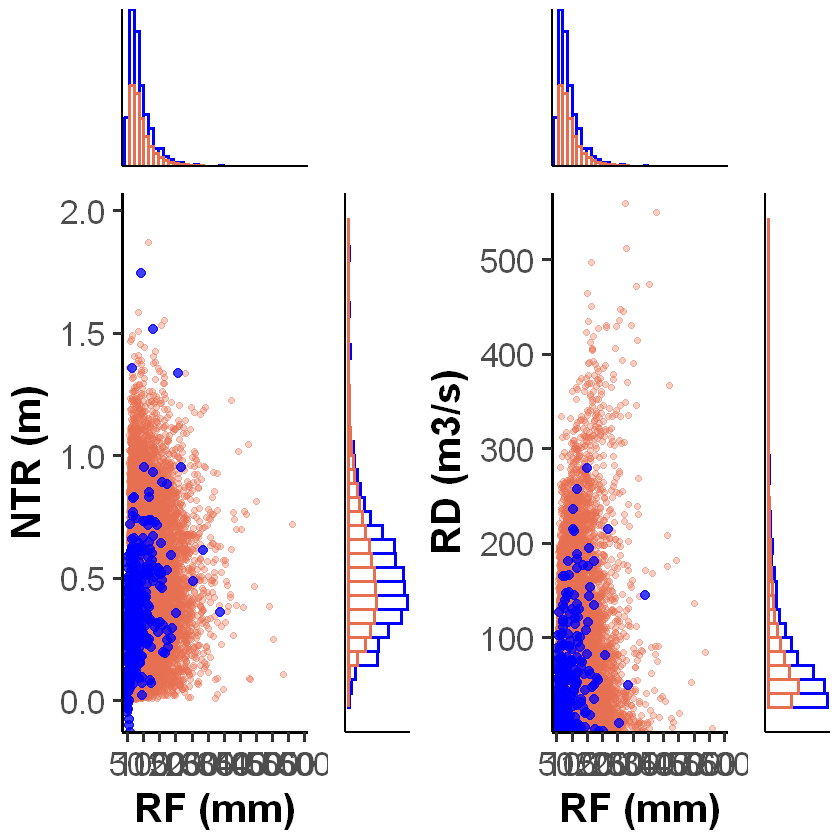

In [64]:
# install.packages(c("ggplot2", "cowplot"))
library(ggplot2)
library(cowplot)

# ---- helper: nice RD breaks so labels don't get clipped/truncated ----
rd_breaks <- function(lim, by = 500) {
  start <- ceiling(lim[1] / by) * by
  end   <- floor(lim[2] / by) * by
  if (start > end) return(pretty(lim, n = 4))
  seq(from = start, to = end, by = by)
}

obs_col <- "blue"
sim_col <- "#E76F51"   # keep your simulated color (or change if you want)

make_joint_density_hist_aligned_clipped <- function(obs_x, obs_y,
                                                    sim_x, sim_y,
                                                    xlab, ylab,
                                                    xlim, ylim,
                                                    bins = 35,
                                                    top_h = 0.28,
                                                    right_w = 0.28,
                                                    alpha_sim = 0.35,
                                                    size_sim  = 1.6,
                                                    alpha_obs = 0.75,
                                                    size_obs  = 2.5,
                                                    rd_break_by = 500) {
  
  d <- rbind(
    data.frame(x = sim_x, y = sim_y, group = "Simulated"),
    data.frame(x = obs_x, y = obs_y, group = "Observed")
  )
  d$group <- factor(d$group, levels = c("Observed", "Simulated"))
  
  # Common margins
  common_margin <- margin(6, 6, 6, 6)
  
  # Scatter gets EXTRA right margin to avoid clipping last tick label (e.g., 2000)
  scatter_margin <- margin(6, 12, 6, 6)
  
  # ---- Main scatter (separate layers for sim/obs control) ----
  p_scatter <- ggplot() +
    geom_point(
      data = subset(d, group == "Simulated"),
      aes(x = x, y = y, colour = group),
      alpha = alpha_sim, size = size_sim
    ) +
    geom_point(
      data = subset(d, group == "Observed"),
      aes(x = x, y = y, colour = group),
      colour = "blue",
      alpha = alpha_obs, size = size_obs
    ) +
    scale_colour_manual(
      values = c("Observed" = obs_col, "Simulated" = sim_col)
    ) +
    coord_cartesian(xlim = xlim, ylim = ylim, expand = FALSE) +
    scale_x_continuous(
      breaks = rd_breaks(xlim, by = rd_break_by),
      expand = c(0, 0)
    ) +
    labs(x = xlab, y = ylab) +
    theme_classic(base_size = 24) +
    theme(
      legend.position = "none",
      axis.text.x = element_text(size = 20),  # ← increase tick size
      axis.text.y = element_text(size = 20),  # optional, keep consistent
      axis.title = element_text(face = "bold"),
      plot.margin = scatter_margin
    )
  
  # ---- Top histogram (density-normalized) ----
  p_top <- ggplot(d, aes(x = x, colour = group)) +
    geom_histogram(aes(y = after_stat(density)),
                   bins = bins, fill = NA, linewidth = 0.9) +  
    scale_colour_manual(
      values = c("Observed" = obs_col, "Simulated" = sim_col)
    ) +
    coord_cartesian(xlim = xlim, expand = FALSE) +
    scale_x_continuous(
      breaks = rd_breaks(xlim, by = rd_break_by),
      expand = c(0, 0)
    ) +
    theme_classic(base_size = 18) +
    theme(
      legend.position = "none",
      plot.margin = common_margin,
      axis.title = element_blank(),
      axis.text.x = element_blank(),
      axis.ticks.x = element_blank(),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank()
    )
  
  # ---- Right histogram (density-normalized; histogram of y) ----
  p_right <- ggplot(d, aes(x = y, colour = group)) +
    geom_histogram(aes(y = after_stat(density)),
                   bins = bins, fill = NA, linewidth = 0.9) +
    scale_colour_manual(
      values = c("Observed" = obs_col, "Simulated" = sim_col)
    ) +
    coord_cartesian(xlim = ylim, expand = FALSE) +
    coord_flip() +
    theme_classic(base_size = 18) +
    theme(
      legend.position = "none",
      plot.margin = common_margin,
      axis.title = element_blank(),
      axis.text.x = element_blank(),
      axis.ticks.x = element_blank(),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank()
    )
  
  # ---- Align panels ----
  aligned_top <- align_plots(p_top, p_scatter, align = "v", axis = "lr")
  p_top_a <- aligned_top[[1]]
  p_sc_a  <- aligned_top[[2]]
  
  aligned_right <- align_plots(p_sc_a, p_right, align = "h", axis = "tb")
  p_sc_a2   <- aligned_right[[1]]
  p_right_a <- aligned_right[[2]]
  
  # Blank placeholder (top-right)
  blank <- ggplot() + theme_void() + theme(plot.margin = common_margin)
  
  # ---- 2x2 clipped layout ----
  plot_grid(
    plot_grid(p_top_a, blank, ncol = 2, rel_widths = c(1, right_w)),
    plot_grid(p_sc_a2, p_right_a, ncol = 2, rel_widths = c(1, right_w)),
    nrow = 2,
    rel_heights = c(top_h, 1)
  )
}

# ----------------------------
# Shared limits with requested padding
# ----------------------------
# RD max + 100
xlim_rf_ntr <- range(c(df[[center_Var]], df_simulated$Sim_RF), na.rm = TRUE)
xlim_rf_ntr[2] <- xlim_rf_ntr[2] + 50
# xlim_rd_ntr[1] <- 0

xlim_rf_rd <- range(c(df[[center_Var]], df_simulated$Sim_RF), na.rm = TRUE)
xlim_rf_rd[2] <- xlim_rf_rd[2] + 50
# xlim_rd_rf[1] <- 0

# NTR max + 0.5
ylim_rf_ntr <- range(c(df[[associated_var2]], df_simulated$Sim_NTR), na.rm = TRUE)
ylim_rf_ntr[2] <- ylim_rf_ntr[2] + 0.2
# ylim_rd_ntr[1] <- 0

# RF max + 100
ylim_rf_rd <- range(c(df[[associated_var1]], df_simulated$Sim_RD), na.rm = TRUE)
ylim_rf_rd[2] <- ylim_rf_rd[2] + 10
# ylim_rd_rf[1] <- 0

# ----------------------------
# Two panels
# ----------------------------
p1 <- make_joint_density_hist_aligned_clipped(
  obs_x = df[[center_Var]],
  obs_y = df[[associated_var2]],
  sim_x = df_simulated$Sim_RF,
  sim_y = df_simulated$Sim_NTR,
  xlab  = "RF (mm)",
  ylab  = "NTR (m)",
  xlim  = xlim_rf_ntr,
  ylim  = ylim_rf_ntr,
  bins  = 35,
  top_h = 0.28,
  right_w = 0.28,
  alpha_obs = 0.75,
  size_obs  = 2.5,
  rd_break_by = 50
)

p2 <- make_joint_density_hist_aligned_clipped(
  obs_x = df[[center_Var]],
  obs_y = df[[associated_var1]],
  sim_x = df_simulated$Sim_RF,
  sim_y = df_simulated$Sim_RD,
  xlab  = "RF (mm)",
  ylab  = "RD (m3/s)",
  xlim  = xlim_rf_rd,
  ylim  = ylim_rf_rd,
  bins  = 35,
  top_h = 0.28,
  right_w = 0.28,
  alpha_obs = 0.75,
  size_obs  = 2.5,
  rd_break_by = 50
)

final_plot <- plot_grid(p1, p2, ncol = 2)
print(final_plot)

ggsave("Simulated_vs_Observed_POT_RF_LS.png",
       final_plot, width = 12, height = 6, dpi = 300, bg = "white")
# ggsave("Simulated_vs_Observed_Normalized_Marginals_Aligned_Clipped.pdf",
#        final_plot, width = 12, height = 6)

## Finding Marginals & Applying Stationary Copulas

In this section, we will use dtationary GP and Copula.

In [22]:
library(readr)
library(fitdistrplus)
library(evir)
library(network)
library(VineCopula)
library(copula)
library(evd)
library(MASS)
library(fitdistrplus)
library(lubridate)
library(dplyr)
library(fitdistrplus)
library(pracma)
library(fGarch)


Attaching package: 'evir'


The following object is masked _by_ '.GlobalEnv':

    qgpd


The following object is masked from 'package:ggplot2':

    qplot


The following objects are masked from 'package:evd':

    dgev, dgpd, pgev, pgpd, qgev, qgpd, rgev, rgpd



'network' 1.19.0 (2024-12-08), part of the Statnet Project
* 'news(package="network")' for changes since last version
* 'citation("network")' for citation information
* 'https://statnet.org' for help, support, and other information



Attaching package: 'copula'


The following objects are masked from 'package:pracma':

    polylog, psi, sinc


The following object is masked from 'package:lubridate':

    interval


The following object is masked from 'package:VineCopula':

    pobs




In [724]:
# Check where you are now
# getwd()
# list.files()  # should show your CSV name; if not, you're in the wrong folder

# Set to the folder that contains the CSV
setwd("C:/Users/sadaf/Desktop/Generating_Boundary_Conditions/POT_24hr_Jan26/Trivariate/OceanSprings/Reanalysis/Stationary")


## Center Variable Stationary GP

In [725]:
center_Var <- "POT_RF"  # Center variable for POT analysis
associated_var1 <- "Max_RD_in_5d"  # First associated variable
associated_var2 <- "Max_NTR_in_5d"  # Second associated variable
n_events_year <- 10  # Adjust as per your data
u <- 37 # Center Variable Threshold

In [726]:
# Load data
# df <- read.csv("POT_RF_Stationary_NTR_RD_GHCN_NOAA_USGS_5.csv")  
df <- read.csv("POT_RF_Stationary_NTR_RD_AORC_CDS_GloFAS_10.csv")  

df <- na.omit(df)
df <- df[df[[associated_var1]] != 0, ]
df <- df[df[[associated_var2]] != 0, ]
df <- df[is.finite(df[[center_Var]]), ]

exceedance_rf <- df[[center_Var]][df[[center_Var]] >= u] 

mask <- df[[center_Var]] - u > 0

gpd_fit <- fpot(df[[center_Var]], threshold = u, model = 'gpd')  # GPD fit
xi_rf    <- gpd_fit$estimate["shape"]
# xi_rf <- 0.2
sigma_rf <- gpd_fit$estimate["scale"]
# sigma_rf <- 30
# Compute stationary RF CDF
u_rf <- evd::pgpd(exceedance_rf, loc = u, scale = sigma_rf, shape = xi_rf)


## Associated Variables Marginals

In [738]:

rd_vals <- df[[associated_var1]][mask]
select_best_fit <- function(fit_list) {
  gof <- gofstat(fit_list)
  best_aic <- which.min(gof$aic)
  best_bic <- which.min(gof$bic)
  
  cat("Best AIC fit:", names(fit_list)[best_aic], "\n")
  cat("Best BIC fit:", names(fit_list)[best_bic], "\n")
  return(list(
    AIC_best = fit_list[[best_aic]],
    BIC_best = fit_list[[best_bic]],
    gof_summary = gof
  ))
}

# Example usage:
fits <- list(
  gamma = fitdist(rd_vals, "gamma"),
  # lnorm = fitdist(rd_vals, "lnorm"),
  weibull = fitdist(rd_vals, "weibull"),
  norm = fitdist(rd_vals, "norm"),
  exp = fitdist(rd_vals, "exp")
)

best_fits_rd <- select_best_fit(fits)

# Extract fitted distribution name
best_fit_name_rd <- best_fits_rd$AIC_best$distname

# Extract parameter estimates
params_rd <- best_fits_rd$AIC_best$estimate

# Compute uniform marginals based on best distribution
if (best_fit_name_rd == "exp") {
  rd_vals <- df[[associated_var1]][mask]
  u_rd <- pexp(rd_vals, rate = as.numeric(params_rd["rate"]))
  
} else if (best_fit_name_rd == "gamma") {
  rd_vals <- df[[associated_var1]][mask]
  u_rd <- pgamma(rd_vals,
                 shape = as.numeric(params_rd["shape"]),
                 rate = as.numeric(params_rd["rate"]))
  
} else if (best_fit_name_rd == "lnorm") {
  rd_vals <- df[[associated_var1]][mask]
  u_rd <- plnorm(rd_vals,
                 meanlog = as.numeric(params_rd["meanlog"]),
                 sdlog = as.numeric(params_rd["sdlog"]))
  
} else if (best_fit_name_rd == "weibull") {
  rd_vals <- df[[associated_var1]][mask]
  u_rd <- pweibull(rd_vals,
                   shape = as.numeric(params_rd["shape"]),
                   scale = as.numeric(params_rd["scale"]))
  
} else if (best_fit_name_rd == "norm") {
  rd_vals <- df[[associated_var1]][mask]
  u_rd <- pnorm(rd_vals,
                mean = as.numeric(params_rd["mean"]),
                sd = as.numeric(params_rd["sd"]))
  
} else {
  stop("Unsupported distribution for CDF transformation.")
}
##################

ntr_vals <- df[[associated_var2]][mask]
min_val <- min(ntr_vals)
if (min_val <= 0) {
  shift_val <- abs(min_val) + 1e-6  # Add a small buffer to avoid zero
  ntr_vals <- ntr_vals + shift_val
  df[[associated_var2]][mask] <- df[[associated_var2]][mask] + shift_val
}
ntr_vals <- df[[associated_var2]][mask]

select_best_fit <- function(fit_list) {
  gof <- gofstat(fit_list)
  best_aic <- which.min(gof$aic)
  best_bic <- which.min(gof$bic)
  
  cat("Best AIC fit:", names(fit_list)[best_aic], "\n")
  cat("Best BIC fit:", names(fit_list)[best_bic], "\n")
  return(list(
    AIC_best = fit_list[[best_aic]],
    BIC_best = fit_list[[best_bic]],
    gof_summary = gof
  ))
}

# Example usage:
fits <- list(
  gamma = fitdist(ntr_vals, "gamma"),
  lnorm = fitdist(ntr_vals, "lnorm"),
  weibull = fitdist(ntr_vals, "weibull"),
  norm = fitdist(ntr_vals, "norm"),
  exp = fitdist(ntr_vals, "exp")
)

best_fits_ntr <- select_best_fit(fits)

# Extract fitted distribution name
best_fit_name_ntr <- best_fits_ntr$AIC_best$distname

# Extract parameter estimates
params_ntr <- best_fits_ntr$AIC_best$estimate

# Compute uniform marginals based on best distribution
if (best_fit_name_ntr == "exp") {
  ntr_vals <- df[[associated_var2]][mask]
  u_ntr <- pexp(ntr_vals, rate = as.numeric(params_ntr["rate"]))
  
} else if (best_fit_name_ntr == "gamma") {
  ntr_vals <- df[[associated_var2]][mask]
  u_ntr <- pgamma(ntr_vals,
                 shape = as.numeric(params_ntr["shape"]),
                 rate = 5) #as.numeric(params_ntr["rate"]))
  
} else if (best_fit_name_ntr == "lnorm") {
  ntr_vals <- df[[associated_var2]][mask]
  u_ntr <- plnorm(ntr_vals,
                 meanlog = as.numeric(params_ntr["meanlog"]),
                 sdlog = as.numeric(params_ntr["sdlog"]))
  
} else if (best_fit_name_ntr == "weibull") {
  ntr_vals <- df[[associated_var2]][mask]
  u_ntr <- pweibull(ntr_vals,
                   shape = as.numeric(params_ntr["shape"]),
                   scale = as.numeric(params_ntr["scale"]))
  
} else if (best_fit_name_ntr == "norm") {
  ntr_vals <- df[[associated_var2]][mask]
  u_ntr <- pnorm(ntr_vals,
                mean = as.numeric(params_ntr["mean"]),
                sd = as.numeric(params_ntr["sd"]))
  
} else {
  stop("Unsupported distribution for CDF transformation.")
}




Best AIC fit: gamma 
Best BIC fit: gamma 
Best AIC fit: gamma 
Best BIC fit: gamma 


In [739]:
copula_df <- data.frame(
  U_RF = u_rf,
  U_NTR = u_ntr,
  U_RD = u_rd
)

## Stationary Copula

In [740]:
set.seed(123)

u_data <- copula_df

fit23 <- BiCopSelect(u1 = u_data[, 2], u2 = u_data[, 3], familyset = NA, selectioncrit = "AIC", indeptest = TRUE)#, rotations=FALSE)

Matrix <- c(3, 2, 1,
            0, 2, 1,
            0, 0, 1)
Matrix <- matrix(Matrix, 3, 3)

RVM <- RVineMatrix(Matrix = Matrix,
                   family = matrix(0, 3, 3),  # placeholders
                   par = matrix(0, 3, 3),
                   par2 = matrix(0, 3, 3),
                   names = c("NTR", "RF", "RD"))


### Step 4: Fit the C-vine with this structure
cvine_fit <- RVineCopSelect(data = u_data,
                            Matrix = RVM$Matrix,
                            familyset = c(1, 3, 4, 5, 6),  # copula families
                            selectioncrit = "AIC",
                            rotations = FALSE,
                            indeptest = TRUE)

summary(cvine_fit)

tree   edge | family  cop   par  par2 |  tau   utd   ltd 
-------------------------------------------------------- 
   1    1,3 |      6    J  1.30  0.00 | 0.15  0.29     -
        1,2 |      1    N  0.32  0.00 | 0.21     -     -
   2  2,3;1 |      5    F  1.07  0.00 | 0.12     -     -
---
type: C-vine    logLik: 56.09    AIC: -106.18    BIC: -93.94    
---
1 <-> U_RF,   2 <-> U_NTR,   3 <-> U_RD

In [741]:
simulated_u <- RVineSim(1700, cvine_fit)

# Extract simulated columns
u1 <- simulated_u[, 1]  # U_RF
u2 <- simulated_u[, 2]  # U_NTR
u3 <- simulated_u[, 3]  # U_RD

# Bivariate CDF for (U_RF, U_NTR)
C12 <- BiCopCDF(u1, u2, family = cvine_fit$family[3,2],
                par = cvine_fit$par[3,2],
                par2 = cvine_fit$par2[3,2])

# Bivariate CDF for (U_RF, U_RD)
C13 <- BiCopCDF(u1, u3, family = cvine_fit$family[3,1],
                par = cvine_fit$par[3,1],
                par2 = cvine_fit$par2[3,1])

# Bivariate CDF for (U_NTR, U_RD)
C23 <- BiCopCDF(u2, u3, family = fit23$family,
                par = fit23$par,
                par2 = fit23$par2)

# Combine the simulated values into a matrix
u_matrix <- as.matrix(cbind(u1, u2, u3))

# Compute the trivariate CDF for all simulated points
C123 <- RVineCDF(u_matrix, cvine_fit)

sim_results <- data.frame(
  U_RF  = u1,
  U_NTR = u2,
  U_RD  = u3,
  C12   = C12,
  C13   = C13,
  C23   = C23,
  C123  = C123
)


# Assuming you have u1, u2, u3 and C12, C13, C23, C123 from previous steps


# Compute joint exceedance probability
p_exceed <- 1 - u1 - u2 - u3 + C12 + C13 + C23 - C123

# Ensure probabilities are valid (>=0)
p_exceed[p_exceed < 1e-12] <- NA  # Avoid negative or zero

# Compute return period in years
T_years <- 1 / (p_exceed * n_events_year)

# Add to dataframe
sim_results$ReturnPeriod_Trivariate <- T_years

# Assuming you have u1, u2, u3 and C12, C13, C23, C123 from previous steps


# Compute joint exceedance probability
p_exceed_bivariate <- 1 - u1 - u2 + C12 

# Ensure probabilities are valid (>=0)
p_exceed_bivariate[p_exceed_bivariate < 1e-12] <- NA  # Avoid negative or zero

# Compute return period in years
T_years_bivariate <- 1 / (p_exceed_bivariate * n_events_year)

# Add to dataframe
sim_results$ReturnPeriod_Bivariate <- T_years_bivariate


## Back Transform to Original Scale

In [742]:

df_simulated <- as.data.frame(sim_results)

# Get best distribution name
best_fit_name_rd <- best_fits_rd$AIC_best$distname

# Get parameter estimates
params_rd <- best_fits_rd$AIC_best$estimate

# Simulated uniform samples (U_RD or U_RF, depending on context)
u_vals_rd <- df_simulated$U_RD  # or U_RF depending on variable

# Inverse transform from uniform [0,1] to original scale
if (best_fit_name_rd == "exp") {
  u_vals_rd <- df_simulated$U_RD
  simulated_vals_rd <- qexp(u_vals_rd, rate = as.numeric(params_rd["rate"]))
  
} else if (best_fit_name_rd == "gamma") {
  u_vals_rd <- df_simulated$U_RD
  simulated_vals_rd <- qgamma(u_vals_rd,
                              shape = as.numeric(params_rd["shape"]),
                              rate = as.numeric(params_rd["rate"]))
  
} else if (best_fit_name_rd == "lnorm") {
  u_vals_rd <- df_simulated$U_RD
  simulated_vals_rd <- qlnorm(u_vals_rd,
                              meanlog = as.numeric(params_rd["meanlog"]),
                              sdlog = as.numeric(params_rd["sdlog"]))
  
} else if (best_fit_name_rd == "weibull") {
  u_vals_rd <- df_simulated$U_RD
  simulated_vals_rd <- qweibull(u_vals_rd,
                                shape = as.numeric(params_rd["shape"]),
                                scale = as.numeric(params_rd["scale"]))
  
} else if (best_fit_name_rd == "norm") {
  u_vals_rd <- df_simulated$U_RD
  simulated_vals_rd <- qnorm(u_vals_rd,
                             mean = as.numeric(params_rd["mean"]),
                             sd = as.numeric(params_rd["sd"]))
  
} else {
  stop("Unsupported distribution for inverse transform.")
}

#####################

# Get best distribution name
best_fit_name_ntr <- best_fits_ntr$AIC_best$distname

# Get parameter estimates
params_ntr <- best_fits_ntr$AIC_best$estimate

# Simulated uniform samples (U_RD or U_ntr, depending on context)
u_vals_ntr <- df_simulated$U_NTR  # or U_ntr depending on variable

# Inverse transform from uniform [0,1] to original scale
if (best_fit_name_ntr == "exp") {
  u_vals_ntr <- df_simulated$U_NTR
  simulated_vals_ntr <- qexp(u_vals_ntr, rate = as.numeric(params_ntr["rate"]))
  
} else if (best_fit_name_ntr == "gamma") {
  u_vals_ntr <- df_simulated$U_NTR
  simulated_vals_ntr <- qgamma(u_vals_ntr,
                              shape = as.numeric(params_ntr["shape"]),
                              rate = 5) #as.numeric(params_ntr["rate"]))
  
} else if (best_fit_name_ntr == "lnorm") {
  u_vals_ntr <- df_simulated$U_NTR
  simulated_vals_ntr <- qlnorm(u_vals_ntr,
                              meanlog = as.numeric(params_ntr["meanlog"]),
                              sdlog = as.numeric(params_ntr["sdlog"]))
  
} else if (best_fit_name_ntr == "weibull") {
  u_vals_ntr <- df_simulated$U_NTR
  simulated_vals_ntr <- qweibull(u_vals_ntr,
                                shape = as.numeric(params_ntr["shape"]),
                                scale = as.numeric(params_ntr["scale"]))
  
} else if (best_fit_name_ntr == "norm") {
  u_vals_ntr <- df_simulated$U_NTR
  simulated_vals_ntr <- qnorm(u_vals_ntr,
                             mean = as.numeric(params_ntr["mean"]),
                             sd = as.numeric(params_ntr["sd"]))
  
} else {
  stop("Unsupported distribution for inverse transform.")
}



simulated_rf <- evd::qgpd(df_simulated$U_RF, loc = u, scale = sigma_rf, shape = xi_rf)


In [743]:
df_simulated$Sim_NTR <- simulated_vals_ntr
df_simulated$Sim_RD <- simulated_vals_rd
df_simulated$Sim_RF <- simulated_rf
df_simulated <- na.omit(df_simulated)

# Save the final results
write.csv(df_simulated,
          "Simulated_Backtransformed_RF_NTR_RD.csv", row.names = FALSE)

## Visualization

In [744]:
# # df_simulated <- read.csv("Simulated_Backtransformed_NTR_RF_RD.csv")

# # Set 3x2 layout for marginal comparisons
# # Set 3x2 layout for marginal comparisons
# par(mfrow = c(3, 2))

# # 1. RF (Observed vs Simulated)
# hist(df[[center_Var]], breaks = 30, probability = TRUE,
#      main = "Observed RF", xlab = "RF", col = rgb(0, 0, 1, 0.5), border = "white")
# hist(df_simulated$Sim_RF, breaks = 30, probability = TRUE,
#      main = "Simulated RF", xlab = "Simulated RF", col = rgb(1, 0, 0, 0.5), border = "white")

# # 2. NTR (Observed vs Simulated)
# hist(df[[associated_var2]], breaks = 30, probability = TRUE,
#      main = "Observed NTR", xlab = "NTR", col = rgb(0, 0, 1, 0.5), border = "white")
# hist(df_simulated$Sim_NTR, breaks = 30, probability = TRUE,
#      main = "Simulated NTR", xlab = "Simulated NTR", col = rgb(1, 0, 0, 0.5), border = "white")

# # 3. RD (Observed vs Simulated)
# hist(df[[associated_var1]], breaks = 30, probability = TRUE,
#      main = "Observed RD", xlab = "RD", col = rgb(0, 0, 1, 0.5), border = "white")
# hist(df_simulated$Sim_RD, breaks = 30, probability = TRUE,
#      main = "Simulated RD", xlab = "Simulated RD", col = rgb(1, 0, 0, 0.5), border = "white")


In [745]:
# # 1×2 layout
# par(mfrow = c(1, 2))

# # Shared limits from both datasets
# xlim_rf_ntr <- range(c(df[[center_Var]], df_simulated$Sim_RF), na.rm = TRUE)
# ylim_rf_ntr <- range(c(df[[associated_var2]], df_simulated$Sim_NTR), na.rm = TRUE)

# xlim_rf_rd  <- range(c(df[[center_Var]], df_simulated$Sim_RF), na.rm = TRUE)
# ylim_rf_rd  <- range(c(df[[associated_var1]], df_simulated$Sim_RD), na.rm = TRUE)

# # --- 1) RD vs NTR: plot Sim first, then overlay Obs ---
# plot(df_simulated$Sim_RF, df_simulated$Sim_NTR,
#      xlab = "RF", ylab = "NTR",
#      main = "Simulated vs Observed: RF vs NTR",
#      pch = 19, col = rgb(1, 0, 0, 0.5),
#      xlim = xlim_rf_ntr, ylim = ylim_rf_ntr)

# points(df[[center_Var]], df[[associated_var2]],
#        pch = 19, col = rgb(0, 0, 1, 0.5))

# legend("topright", legend = c("Simulated", "Observed"),
#        col = c("red", "blue"), pch = 19, bty = "n")

# # --- 2) RD vs RF: plot Sim first, then overlay Obs ---
# plot(df_simulated$Sim_RF, df_simulated$Sim_RD,
#      xlab = "RF", ylab = "RD",
#      main = "Simulated vs Observed: RF vs RD",
#      pch = 19, col = rgb(1, 0, 0, 0.5),
#      xlim = xlim_rf_rd, ylim = ylim_rf_rd)

# points(df[[center_Var]], df[[associated_var1]],
#        pch = 19, col = rgb(0, 0, 1, 0.5))

# legend("topright", legend = c("Simulated", "Observed"),
#        col = c("red", "blue"), pch = 19, bty = "n")

Coordinate system already present. Adding new coordinate system, which will replace the existing one.
Coordinate system already present. Adding new coordinate system, which will replace the existing one.


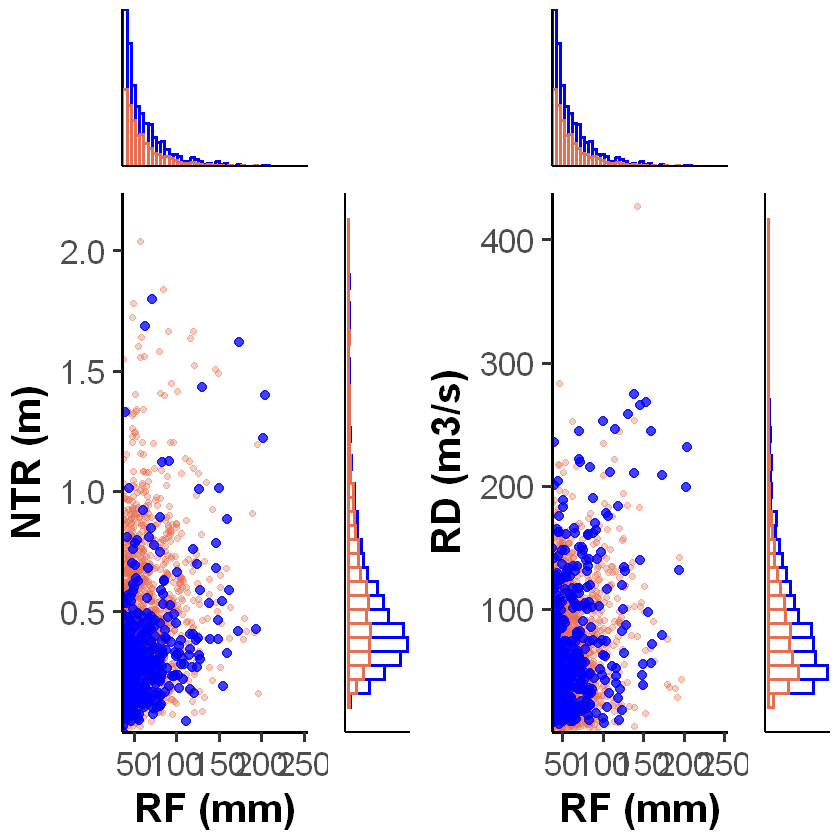

In [746]:
# install.packages(c("ggplot2", "cowplot"))
library(ggplot2)
library(cowplot)

# ---- helper: nice RD breaks so labels don't get clipped/truncated ----
rd_breaks <- function(lim, by = 500) {
  start <- ceiling(lim[1] / by) * by
  end   <- floor(lim[2] / by) * by
  if (start > end) return(pretty(lim, n = 4))
  seq(from = start, to = end, by = by)
}

obs_col <- "blue"
sim_col <- "#E76F51"   # keep your simulated color (or change if you want)

make_joint_density_hist_aligned_clipped <- function(obs_x, obs_y,
                                                    sim_x, sim_y,
                                                    xlab, ylab,
                                                    xlim, ylim,
                                                    bins = 35,
                                                    top_h = 0.28,
                                                    right_w = 0.28,
                                                    alpha_sim = 0.35,
                                                    size_sim  = 1.6,
                                                    alpha_obs = 0.75,
                                                    size_obs  = 2.5,
                                                    rd_break_by = 500) {
  
  d <- rbind(
    data.frame(x = sim_x, y = sim_y, group = "Simulated"),
    data.frame(x = obs_x, y = obs_y, group = "Observed")
  )
  d$group <- factor(d$group, levels = c("Observed", "Simulated"))
  
  # Common margins
  common_margin <- margin(6, 6, 6, 6)
  
  # Scatter gets EXTRA right margin to avoid clipping last tick label (e.g., 2000)
  scatter_margin <- margin(6, 12, 6, 6)
  
  # ---- Main scatter (separate layers for sim/obs control) ----
  p_scatter <- ggplot() +
    geom_point(
      data = subset(d, group == "Simulated"),
      aes(x = x, y = y, colour = group),
      alpha = alpha_sim, size = size_sim
    ) +
    geom_point(
      data = subset(d, group == "Observed"),
      aes(x = x, y = y, colour = group),
      colour = "blue",
      alpha = alpha_obs, size = size_obs
    ) +
    scale_colour_manual(
      values = c("Observed" = obs_col, "Simulated" = sim_col)
    ) +
    coord_cartesian(xlim = xlim, ylim = ylim, expand = FALSE) +
    scale_x_continuous(
      breaks = rd_breaks(xlim, by = rd_break_by),
      expand = c(0, 0)
    ) +
    labs(x = xlab, y = ylab) +
    theme_classic(base_size = 24) +
    theme(
      legend.position = "none",
      axis.text.x = element_text(size = 20),  # ← increase tick size
      axis.text.y = element_text(size = 20),  # optional, keep consistent
      axis.title = element_text(face = "bold"),
      plot.margin = scatter_margin
    )
  
  # ---- Top histogram (density-normalized) ----
  p_top <- ggplot(d, aes(x = x, colour = group)) +
    geom_histogram(aes(y = after_stat(density)),
                   bins = bins, fill = NA, linewidth = 0.9) +  
    scale_colour_manual(
      values = c("Observed" = obs_col, "Simulated" = sim_col)
    ) +
    coord_cartesian(xlim = xlim, expand = FALSE) +
    scale_x_continuous(
      breaks = rd_breaks(xlim, by = rd_break_by),
      expand = c(0, 0)
    ) +
    theme_classic(base_size = 18) +
    theme(
      legend.position = "none",
      plot.margin = common_margin,
      axis.title = element_blank(),
      axis.text.x = element_blank(),
      axis.ticks.x = element_blank(),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank()
    )
  
  # ---- Right histogram (density-normalized; histogram of y) ----
  p_right <- ggplot(d, aes(x = y, colour = group)) +
    geom_histogram(aes(y = after_stat(density)),
                   bins = bins, fill = NA, linewidth = 0.9) +
    scale_colour_manual(
      values = c("Observed" = obs_col, "Simulated" = sim_col)
    ) +
    coord_cartesian(xlim = ylim, expand = FALSE) +
    coord_flip() +
    theme_classic(base_size = 18) +
    theme(
      legend.position = "none",
      plot.margin = common_margin,
      axis.title = element_blank(),
      axis.text.x = element_blank(),
      axis.ticks.x = element_blank(),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank()
    )
  
  # ---- Align panels ----
  aligned_top <- align_plots(p_top, p_scatter, align = "v", axis = "lr")
  p_top_a <- aligned_top[[1]]
  p_sc_a  <- aligned_top[[2]]
  
  aligned_right <- align_plots(p_sc_a, p_right, align = "h", axis = "tb")
  p_sc_a2   <- aligned_right[[1]]
  p_right_a <- aligned_right[[2]]
  
  # Blank placeholder (top-right)
  blank <- ggplot() + theme_void() + theme(plot.margin = common_margin)
  
  # ---- 2x2 clipped layout ----
  plot_grid(
    plot_grid(p_top_a, blank, ncol = 2, rel_widths = c(1, right_w)),
    plot_grid(p_sc_a2, p_right_a, ncol = 2, rel_widths = c(1, right_w)),
    nrow = 2,
    rel_heights = c(top_h, 1)
  )
}

# ----------------------------
# Shared limits with requested padding
# ----------------------------
# RD max + 100
xlim_rf_ntr <- range(c(df[[center_Var]], df_simulated$Sim_RF), na.rm = TRUE)
xlim_rf_ntr[2] <- xlim_rf_ntr[2] + 50
# xlim_rd_ntr[1] <- 0

xlim_rf_rd <- range(c(df[[center_Var]], df_simulated$Sim_RF), na.rm = TRUE)
xlim_rf_rd[2] <- xlim_rf_rd[2] + 50
# xlim_rd_rf[1] <- 0

# NTR max + 0.5
ylim_rf_ntr <- range(c(df[[associated_var2]], df_simulated$Sim_NTR), na.rm = TRUE)
ylim_rf_ntr[2] <- ylim_rf_ntr[2] + 0.2
# ylim_rd_ntr[1] <- 0

# RF max + 100
ylim_rf_rd <- range(c(df[[associated_var1]], df_simulated$Sim_RD), na.rm = TRUE)
ylim_rf_rd[2] <- ylim_rf_rd[2] + 10
# ylim_rd_rf[1] <- 0

# ----------------------------
# Two panels
# ----------------------------
p1 <- make_joint_density_hist_aligned_clipped(
  obs_x = df[[center_Var]],
  obs_y = df[[associated_var2]],
  sim_x = df_simulated$Sim_RF,
  sim_y = df_simulated$Sim_NTR,
  xlab  = "RF (mm)",
  ylab  = "NTR (m)",
  xlim  = xlim_rf_ntr,
  ylim  = ylim_rf_ntr,
  bins  = 35,
  top_h = 0.28,
  right_w = 0.28,
  alpha_obs = 0.75,
  size_obs  = 2.5,
  rd_break_by = 50
)

p2 <- make_joint_density_hist_aligned_clipped(
  obs_x = df[[center_Var]],
  obs_y = df[[associated_var1]],
  sim_x = df_simulated$Sim_RF,
  sim_y = df_simulated$Sim_RD,
  xlab  = "RF (mm)",
  ylab  = "RD (m3/s)",
  xlim  = xlim_rf_rd,
  ylim  = ylim_rf_rd,
  bins  = 35,
  top_h = 0.28,
  right_w = 0.28,
  alpha_obs = 0.75,
  size_obs  = 2.5,
  rd_break_by = 50
)

final_plot <- plot_grid(p1, p2, ncol = 2)
print(final_plot)

ggsave("Simulated_vs_Observed_POT_RF.png",
       final_plot, width = 12, height = 6, dpi = 300, bg = "white")
# ggsave("Simulated_vs_Observed_Normalized_Marginals_Aligned_Clipped.pdf",
#        final_plot, width = 12, height = 6)